## Tasmanian Conditioning
This notebook exists to process hand-scored data from CCNL planarian conditioning projects that follow the protocls described in [James et al. (2025)](https://drive.google.com/file/d/1QFx8QHdXEkjAiJImBWZC_EdjRTzK_7hg/view?usp=drive_link). The data can be found [here](https://docs.google.com/spreadsheets/d/1M-xnRcIi3IS6-G30y5ylytBrqeMi3pINym3OKOTZn3c/edit?usp=sharing). This notebook is geared for reporting sums on a day.

## Import packages and set filepaths.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Set CSV address variable and define savepath for images and shit
CSV_address = "../hand_scored_datasheets/Tasmanian_hand_scored_ZK_20260120.csv"  # Replace with your actual file path
SAVE_PATH = "../figures/Tasmanian_Lineplot"

# Import the CSV
df = pd.read_csv(CSV_address)

# Report unique runs and troupes
unique_runs = df['Run'].nunique()
unique_troupes = df['Troupe'].nunique()

print(f"Unique troupes: {sorted(df['Troupe'].unique())}")
print(f"Number of unique runs: {unique_runs}")
print(f"Number of unique troupes: {unique_troupes}")
print(f"Troupes and runs agree? {unique_runs / unique_troupes == 8}.")

Unique troupes: ['TC-1', 'TC-2', 'TC-3', 'TC-4', 'TC-5', 'TC-6', 'TC-7', 'TC-MI-1', 'TP-1', 'TP-2', 'TP-3', 'TP-4']
Number of unique runs: 96
Number of unique troupes: 12
Troupes and runs agree? True.


## Define and deploy data analysis function.

In [4]:
def analyze_raw_counts(troupes=None, days=None, verbose=True):
    """
    Process behavioral data and create summary dataframe.
    
    Parameters:
    troupes (list): List of troupe names to include. If None, includes all troupes.
    days (list): List of day numbers to include. If None, includes all days.
    verbose (bool): If True, print debugging information.
    
    Returns:
    pandas.DataFrame: Summary dataframe with columns Troupe, Worm, Day, CRturn, CRcon, UCRturn, UCRcon
                     Sorted by Troupe, then Worm, then Day
    """

    # Create behavioral columns off of Worm numbers and response behavior type. We will make sure these are numeric so that summing operations work.
    behavioral_columns = []
    for behavior in ['CRturn', 'CRcon', 'UCRturn', 'UCRcon']:
        for worm in range(1, 7):
            col_name = f"{behavior}_W{worm}"
            behavioral_columns.append(col_name)
    
    # Convert behavioral columns to numeric, replacing any non-numeric values with 0
    df_numeric = df.copy()
    for col in behavioral_columns:
        if col in df_numeric.columns:
            df_numeric[col] = pd.to_numeric(df_numeric[col], errors='coerce').fillna(0) # Uses Pandas to force numeric, fill 0 if needed
    
    if verbose:
        print("Sample of data types after conversion:")
        print(df_numeric[behavioral_columns[:4]].dtypes)
    
    # Use all troupes and days if not specified
    if troupes is None:
        troupes = df_numeric['Troupe'].unique()
    if days is None:
        days = df_numeric['Day'].unique()
    
    if verbose:
        print(f"\nLooking for troupes: {troupes}")
        print(f"Looking for days: {days}")
    
    # Filter dataframe based on specified troupes and days
    filtered_df = df_numeric[df_numeric['Troupe'].isin(troupes) & df_numeric['Day'].isin(days)].copy()
    
    if verbose:
        print(f"Filtered dataframe shape: {filtered_df.shape}")
    
    # Initialize list to store results
    results = []
    
    # Process each troupe/day combination
    for troupe in troupes:
        for day in days:
            # Get data for this troupe/day combination
            subset = filtered_df[(filtered_df['Troupe'] == troupe) & (filtered_df['Day'] == day)]
            
            if len(subset) == 0:
                if verbose:
                    print(f"No data found for Troupe: {troupe}, Day: {day}")
                continue
            
            if verbose:
                print(f"Processing Troupe: {troupe}, Day: {day} ({len(subset)} rows)")
                
            # Process each worm (W1 through W6)
            for worm_num in range(1, 7):
                worm_id = f"W{worm_num}"
                
                # Sum scores for each behavior type for this worm (now properly numeric)
                crturn_sum = subset[f'CRturn_{worm_id}'].sum()
                crcon_sum = subset[f'CRcon_{worm_id}'].sum()
                ucrturn_sum = subset[f'UCRturn_{worm_id}'].sum()
                ucrcon_sum = subset[f'UCRcon_{worm_id}'].sum()
                
                # Add row to results
                results.append({
                    'Troupe': troupe,
                    'Worm': worm_id,
                    'Day': day,
                    'CRturn': crturn_sum,
                    'CRcon': crcon_sum,
                    'UCRturn': ucrturn_sum,
                    'UCRcon': ucrcon_sum
                })
    
    # Create summary dataframe
    summary_df = pd.DataFrame(results)
    
    # Sort the dataframe by Troupe, then Worm, then Day
    if len(summary_df) > 0:
        # Create a custom sort key for worms to ensure W1, W2, ..., W6 order
        summary_df['Worm_sort'] = summary_df['Worm'].str.extract('(\d+)').astype(int)
        
        # Sort by Troupe, then Worm_sort (numeric), then Day
        summary_df = summary_df.sort_values(['Troupe', 'Worm_sort', 'Day']).reset_index(drop=True)
        
        # Drop the temporary sorting column
        summary_df = summary_df.drop('Worm_sort', axis=1)
    
    if verbose:
        print(f"\nFinal summary dataframe shape: {summary_df.shape}")
        if len(summary_df) > 0:
            print("Data is now sorted by: Troupe → Worm → Day")
    
    return summary_df

# Test the function
result = analyze_raw_counts(troupes=['TC-2', 'TC-3', 'TC-4', 'TC-6'], days=[1, 4])

# Display the result - now you'll see all TC-2 W1 data together, then TC-2 W2, etc.
if len(result) > 0:
    print("\nResult dataframe (sorted by Troupe → Worm → Day):")
    print(result.head(15))  # Show first 15 rows
    print(f"\nFull result shape: {result.shape}")
    
    # Show a sample of how the data is organized
    print(f"\nSample organization:")
    print(f"First few unique Troupe-Worm combinations:")
    print(result[['Troupe', 'Worm']].drop_duplicates().head(10))
else:
    print("No results returned!")

Sample of data types after conversion:
CRturn_W1    float64
CRturn_W2    float64
CRturn_W3    float64
CRturn_W4    float64
dtype: object

Looking for troupes: ['TC-2', 'TC-3', 'TC-4', 'TC-6']
Looking for days: [1, 4]
Filtered dataframe shape: (48, 30)
Processing Troupe: TC-2, Day: 1 (6 rows)
Processing Troupe: TC-2, Day: 4 (6 rows)
Processing Troupe: TC-3, Day: 1 (6 rows)
Processing Troupe: TC-3, Day: 4 (6 rows)
Processing Troupe: TC-4, Day: 1 (6 rows)
Processing Troupe: TC-4, Day: 4 (6 rows)
Processing Troupe: TC-6, Day: 1 (6 rows)
Processing Troupe: TC-6, Day: 4 (6 rows)

Final summary dataframe shape: (48, 7)
Data is now sorted by: Troupe → Worm → Day

Result dataframe (sorted by Troupe → Worm → Day):
   Troupe Worm  Day  CRturn  CRcon  UCRturn  UCRcon
0    TC-2   W1    1    30.0    9.0      3.0     6.0
1    TC-2   W1    4    32.0   10.0      4.0     5.0
2    TC-2   W2    1    14.0    1.0      0.0     3.0
3    TC-2   W2    4    22.0    6.0      1.0     0.0
4    TC-2   W3    1    25.

## Define graphing functions.

In [5]:
## This is before I added save stuff
def create_behavior_graphs(troupes=None, days=None, figsize=(15, 10)):
    """
    Create line plots showing behavioral measures with spaced positions for each worm-day combination.
    
    Parameters:
    troupes (list): List of troupe names to include. If None, includes all troupes.
    days (list): List of day numbers to include. If None, includes all days.
    figsize (tuple): Figure size for each troupe's set of plots.
    
    Returns:
    None (displays plots)
    """
    
    # Get the processed data using our analyze_raw_counts function
    processed_data = analyze_raw_counts(troupes=troupes, days=days, verbose=False)
    
    if len(processed_data) == 0:
        print("No data found for the specified troupes and days!")
        return
    
    # Get unique troupes and days from the processed data
    unique_troupes = sorted(processed_data['Troupe'].unique())
    unique_days = sorted(processed_data['Day'].unique())
    
    print(f"Creating graphs for troupes: {unique_troupes}")
    print(f"Days included: {unique_days}")
    
    # Define the four behaviors
    behaviors = ['CRturn', 'CRcon', 'UCRturn', 'UCRcon']
    
    # Create plots for each troupe
    for troupe in unique_troupes:
        # Filter data for this troupe
        troupe_data = processed_data[processed_data['Troupe'] == troupe]
        
        # Create subplot figure (2x2 for 4 behaviors)
        fig, axes = plt.subplots(2, 2, figsize=figsize)
        fig.suptitle(f'{troupe} Responses', fontsize=16, fontweight='bold')
        
        # Flatten axes for easier indexing
        axes_flat = axes.flatten()
        
        # Create a plot for each behavior
        for idx, behavior in enumerate(behaviors):
            ax = axes_flat[idx]
            
            # Create x-positions and labels
            x_positions = []
            day_labels = []
            worm_centers = []  # For worm labels
            y_values = []
            
            # Build positions for each worm-day combination
            current_pos = 1
            worm_lines = []  # Store line segments for each worm
            
            for worm_num in [1, 2, 3, 4, 5, 6]:
                worm_id = f'W{worm_num}'
                worm_x_positions = []
                worm_y_values = []
                
                # Get positions and values for each day for this worm
                for day in unique_days:
                    # Find data for this worm and day
                    worm_day_data = troupe_data[
                        (troupe_data['Worm'] == worm_id) & (troupe_data['Day'] == day)
                    ]
                    
                    if len(worm_day_data) > 0:
                        value = worm_day_data[behavior].iloc[0]
                        x_positions.append(current_pos)
                        day_labels.append(str(day))  # Just the day number
                        y_values.append(value)
                        
                        worm_x_positions.append(current_pos)
                        worm_y_values.append(value)
                    
                    current_pos += 1
                
                # Calculate center position for worm label
                if worm_x_positions:
                    worm_center = (min(worm_x_positions) + max(worm_x_positions)) / 2
                    worm_centers.append((worm_center, f'Worm {worm_num}'))
                
                # Store line data for this worm
                if len(worm_x_positions) > 1:  # Only if we have multiple days to connect
                    worm_lines.append((worm_x_positions, worm_y_values))
                
                # Add spacing between worms
                current_pos += 0.5
            
            # Plot all points in black
            ax.scatter(x_positions, y_values, s=40, color='black', alpha=0.8, zorder=3)
            
            # Plot lines connecting days within each worm - all black
            for worm_x, worm_y in worm_lines:
                ax.plot(worm_x, worm_y, 'o-', linewidth=2, markersize=1, 
                       color='black', alpha=0.7)
            
            # Customize the subplot
            ax.set_xlabel('Total score per day', labelpad=25)  # Added labelpad for spacing
            ax.set_ylabel(f'{behavior} Score')
            ax.set_title(f'{behavior}')
            ax.set_xticks(x_positions)
            ax.set_xticklabels(day_labels)
            ax.grid(True, alpha=0.3)
            
            # Set Y-axis limits with hard cap at 0 but add tiny visual space
            if y_values:
                y_max = max(y_values)
                y_range = y_max if y_max > 0 else 1
                # Keep minimum at 0 but add small buffer at top and tiny space at bottom for visual separation
                ax.set_ylim(-0.05 * y_range, y_max + 0.08 * y_range)  # Tiny negative for visual space
                ax.set_yticks([tick for tick in ax.get_yticks() if tick >= 0])  # Only show ticks >= 0
            
            # Add worm labels positioned between day numbers and x-axis title
            for worm_center, worm_label in worm_centers:
                ax.text(worm_center, -0.15, worm_label, 
                       ha='center', va='center', fontsize=9,
                       transform=ax.get_xaxis_transform(),
                       bbox=dict(boxstyle="round,pad=0.2", facecolor="lightgray", alpha=0.3))
        
        # Adjust layout with more spacing between subplots and extra bottom space for labels
        plt.subplots_adjust(left=0.08, bottom=0.25, right=0.95, top=0.90, 
                           wspace=0.15, hspace=0.55)  # Increased bottom margin
        plt.show()

# # Test the function with specific troupes and days
# print("Creating graphs for specific troupes and days:")
# create_behavior_graphs(troupes=['TC-2', 'TC-3'], days=[1, 4])

def create_behavior_graphs_filtered(troupes=None, days=None, figsize=(15, 10)):
    """
    Create line plots showing behavioral measures with spaced positions for each worm-day combination.
    Filters out worms that have any UCRcon data point less than 4.
    
    Parameters:
    troupes (list): List of troupe names to include. If None, includes all troupes.
    days (list): List of day numbers to include. If None, includes all days.
    figsize (tuple): Figure size for each troupe's set of plots.
    
    Returns:
    None (displays plots)
    """
    
    # Get the processed data using our analyze_raw_counts function
    processed_data = analyze_raw_counts(troupes=troupes, days=days, verbose=False)
    
    if len(processed_data) == 0:
        print("No data found for the specified troupes and days!")
        return
    
    # Filter out worms with any UCRcon value < 4
    excluded_worms = set()
    excluded_worms_display = []  # For nice display formatting
    
    for troupe in processed_data['Troupe'].unique():
        troupe_data = processed_data[processed_data['Troupe'] == troupe]
        for worm in troupe_data['Worm'].unique():
            worm_data = troupe_data[troupe_data['Worm'] == worm]
            # Check if any UCRcon value is less than 4
            if any(worm_data['UCRcon'] < 4):
                excluded_worms.add((troupe, worm))
                # Format for display (e.g., "TC-2 Worm 1")
                worm_num = worm[1:]  # Remove the 'W' to get just the number
                excluded_worms_display.append(f"{troupe} Worm {worm_num}")
    
    # Report excluded worms in a single line
    if excluded_worms_display:
        print(f"Worms excluded due to UCRcon < 4: {excluded_worms_display}")
    else:
        print("No worms excluded due to UCRcon < 4")
    
    # Remove excluded worms from the processed data
    for troupe, worm in excluded_worms:
        processed_data = processed_data[~((processed_data['Troupe'] == troupe) & 
                                        (processed_data['Worm'] == worm))]
    
    if len(processed_data) == 0:
        print("No data remaining after filtering!")
        return
    
    # Get unique troupes and days from the filtered data
    unique_troupes = sorted(processed_data['Troupe'].unique())
    unique_days = sorted(processed_data['Day'].unique())
    
    print(f"Creating graphs for troupes: {unique_troupes}")
    print(f"Days included: {unique_days}")
    
    # Define the four behaviors
    behaviors = ['CRturn', 'CRcon', 'UCRturn', 'UCRcon']
    
    # Create plots for each troupe
    for troupe in unique_troupes:
        # Filter data for this troupe
        troupe_data = processed_data[processed_data['Troupe'] == troupe]
        
        if len(troupe_data) == 0:
            print(f"No data for {troupe} after filtering")
            continue
        
        # Create subplot figure (2x2 for 4 behaviors)
        fig, axes = plt.subplots(2, 2, figsize=figsize)
        fig.suptitle(f'Behavioral Measures - {troupe} (Filtered)', fontsize=16, fontweight='bold')
        
        # Flatten axes for easier indexing
        axes_flat = axes.flatten()
        
        # Create a plot for each behavior
        for idx, behavior in enumerate(behaviors):
            ax = axes_flat[idx]
            
            # Create x-positions and labels
            x_positions = []
            day_labels = []
            worm_centers = []  # For worm labels
            y_values = []
            
            # Build positions for each worm-day combination
            current_pos = 1
            worm_lines = []  # Store line segments for each worm
            
            # Get unique worms for this troupe (after filtering)
            unique_worms = sorted([int(w[1:]) for w in troupe_data['Worm'].unique()])
            
            for worm_num in unique_worms:
                worm_id = f'W{worm_num}'
                worm_x_positions = []
                worm_y_values = []
                
                # Get positions and values for each day for this worm
                for day in unique_days:
                    # Find data for this worm and day
                    worm_day_data = troupe_data[
                        (troupe_data['Worm'] == worm_id) & (troupe_data['Day'] == day)
                    ]
                    
                    if len(worm_day_data) > 0:
                        value = worm_day_data[behavior].iloc[0]
                        x_positions.append(current_pos)
                        day_labels.append(str(day))  # Just the day number
                        y_values.append(value)
                        
                        worm_x_positions.append(current_pos)
                        worm_y_values.append(value)
                    
                    current_pos += 1
                
                # Calculate center position for worm label
                if worm_x_positions:
                    worm_center = (min(worm_x_positions) + max(worm_x_positions)) / 2
                    worm_centers.append((worm_center, f'Worm {worm_num}'))
                
                # Store line data for this worm
                if len(worm_x_positions) > 1:  # Only if we have multiple days to connect
                    worm_lines.append((worm_x_positions, worm_y_values))
                
                # Add spacing between worms
                current_pos += 0.5
            
            # Only proceed if we have data points
            if not x_positions:
                ax.text(0.5, 0.5, f'No data available\nfor {behavior}', 
                       ha='center', va='center', transform=ax.transAxes, fontsize=12)
                ax.set_title(f'{behavior}')
                continue
            
            # Plot all points in black
            ax.scatter(x_positions, y_values, s=60, color='black', alpha=0.8, zorder=3)
            
            # Plot lines connecting days within each worm - all black
            for worm_x, worm_y in worm_lines:
                ax.plot(worm_x, worm_y, 'o-', linewidth=2, markersize=8, 
                       color='black', alpha=0.7)
            
            # Customize the subplot
            ax.set_xlabel('Total score per day', labelpad=25)
            ax.set_ylabel(f'{behavior} Score')
            ax.set_title(f'{behavior}')
            ax.set_xticks(x_positions)
            ax.set_xticklabels(day_labels)
            ax.grid(True, alpha=0.3)
            
            # Set Y-axis limits with hard cap at 0 but add tiny visual space
            if y_values:
                y_max = max(y_values)
                y_range = y_max if y_max > 0 else 1
                ax.set_ylim(-0.05 * y_range, y_max + 0.08 * y_range)
                ax.set_yticks([tick for tick in ax.get_yticks() if tick >= 0])
            
            # Add worm labels positioned between day numbers and x-axis title
            for worm_center, worm_label in worm_centers:
                ax.text(worm_center, -0.15, worm_label, 
                       ha='center', va='center', fontsize=9,
                       transform=ax.get_xaxis_transform(),
                       bbox=dict(boxstyle="round,pad=0.2", facecolor="lightgray", alpha=0.3))
        
        # Adjust layout with more spacing between subplots and extra bottom space for labels
        plt.subplots_adjust(left=0.08, bottom=0.25, right=0.95, top=0.90, 
                           wspace=0.35, hspace=0.45)
        plt.show()

# # Test the filtered function
# print("Creating filtered graphs (excluding worms with UCRcon < 4):")
# create_behavior_graphs_filtered(troupes=['TC-2', 'TC-3'], days=[1, 4])

In [6]:
def create_behavior_graphs(troupes=None, days=None, figsize=(15, 10), SAVE=False):
    """
    Create line plots showing behavioral measures with spaced positions for each worm-day combination.
    
    Parameters:
    troupes (list): List of troupe names to include. If None, includes all troupes.
    days (list): List of day numbers to include. If None, includes all days.
    figsize (tuple): Figure size for each troupe's set of plots.
    SAVE (bool): If True, saves figures to SAVE_PATH. If False, displays plots.
    
    Returns:
    None (displays or saves plots)
    """
    import os
    
    # Get the processed data using our analyze_raw_counts function
    processed_data = analyze_raw_counts(troupes=troupes, days=days, verbose=False)
    
    if len(processed_data) == 0:
        print("No data found for the specified troupes and days!")
        return
    
    # Get unique troupes and days from the processed data
    unique_troupes = sorted(processed_data['Troupe'].unique())
    unique_days = sorted(processed_data['Day'].unique())
    
    print(f"Creating graphs for troupes: {unique_troupes}")
    print(f"Days included: {unique_days}")
    
    # Define the four behaviors
    behaviors = ['CRturn', 'CRcon', 'UCRturn', 'UCRcon']
    saved_files = []
    
    # Create plots for each troupe
    for troupe in unique_troupes:
        # Filter data for this troupe
        troupe_data = processed_data[processed_data['Troupe'] == troupe]
        
        # Create subplot figure (2x2 for 4 behaviors)
        fig, axes = plt.subplots(2, 2, figsize=figsize)
        title = f'{troupe} Responses'
        fig.suptitle(title, fontsize=16, fontweight='bold')
        
        # Flatten axes for easier indexing
        axes_flat = axes.flatten()
        
        # Create a plot for each behavior
        for idx, behavior in enumerate(behaviors):
            ax = axes_flat[idx]
            
            # Create x-positions and labels
            x_positions = []
            day_labels = []
            worm_centers = []  # For worm labels
            y_values = []
            
            # Build positions for each worm-day combination
            current_pos = 1
            worm_lines = []  # Store line segments for each worm
            
            for worm_num in [1, 2, 3, 4, 5, 6]:
                worm_id = f'W{worm_num}'
                worm_x_positions = []
                worm_y_values = []
                
                # Get positions and values for each day for this worm
                for day in unique_days:
                    # Find data for this worm and day
                    worm_day_data = troupe_data[
                        (troupe_data['Worm'] == worm_id) & (troupe_data['Day'] == day)
                    ]
                    
                    if len(worm_day_data) > 0:
                        value = worm_day_data[behavior].iloc[0]
                        x_positions.append(current_pos)
                        day_labels.append(str(day))  # Just the day number
                        y_values.append(value)
                        
                        worm_x_positions.append(current_pos)
                        worm_y_values.append(value)
                    
                    current_pos += 1
                
                # Calculate center position for worm label
                if worm_x_positions:
                    worm_center = (min(worm_x_positions) + max(worm_x_positions)) / 2
                    worm_centers.append((worm_center, f'Worm {worm_num}'))
                
                # Store line data for this worm
                if len(worm_x_positions) > 1:  # Only if we have multiple days to connect
                    worm_lines.append((worm_x_positions, worm_y_values))
                
                # Add spacing between worms
                current_pos += 0.5
            
            # Plot all points in black
            ax.scatter(x_positions, y_values, s=40, color='black', alpha=0.8, zorder=3)
            
            # Plot lines connecting days within each worm - all black
            for worm_x, worm_y in worm_lines:
                ax.plot(worm_x, worm_y, 'o-', linewidth=2, markersize=1, 
                       color='black', alpha=0.7)
            
            # Customize the subplot
            ax.set_xlabel('Total score per day', labelpad=25)  # Added labelpad for spacing
            ax.set_ylabel(f'{behavior} Score')
            ax.set_title(f'{behavior}')
            ax.set_xticks(x_positions)
            ax.set_xticklabels(day_labels)
            ax.grid(True, alpha=0.3)
            
            # Set Y-axis limits with hard cap at 0 but add tiny visual space
            if y_values:
                y_max = max(y_values)
                y_range = y_max if y_max > 0 else 1
                # Keep minimum at 0 but add small buffer at top and tiny space at bottom for visual separation
                ax.set_ylim(-0.05 * y_range, y_max + 0.08 * y_range)  # Tiny negative for visual space
                ax.set_yticks([tick for tick in ax.get_yticks() if tick >= 0])  # Only show ticks >= 0
            
            # Add worm labels positioned between day numbers and x-axis title
            for worm_center, worm_label in worm_centers:
                ax.text(worm_center, -0.15, worm_label, 
                       ha='center', va='center', fontsize=9,
                       transform=ax.get_xaxis_transform(),
                       bbox=dict(boxstyle="round,pad=0.2", facecolor="lightgray", alpha=0.3))
        
        # Adjust layout with more spacing between subplots and extra bottom space for labels
        plt.subplots_adjust(left=0.08, bottom=0.25, right=0.95, top=0.90, 
                           wspace=0.15, hspace=0.55)  # Increased bottom margin
        
        # Save or show the figure
        if SAVE:
            # Clean filename by removing problematic characters
            safe_title = title.replace(' ', '_').replace('-', '_').replace('(', '').replace(')', '')
            filename = f"{safe_title}.png"
            filepath = os.path.join(SAVE_PATH, filename)
            fig.savefig(filepath, dpi=300, bbox_inches='tight')
            saved_files.append(filename)
            plt.close(fig)  # Close to save memory
        else:
            plt.show()
    
    if SAVE and saved_files:
        print(f"Saved {len(saved_files)} files to {SAVE_PATH}:")
        for file in saved_files:
            print(f"  {file}")

def create_behavior_graphs_filtered(troupes=None, days=None, figsize=(15, 10), SAVE=False):
    """
    Create line plots showing behavioral measures with spaced positions for each worm-day combination.
    Filters out worms that have any UCRcon data point less than 4.
    
    Parameters:
    troupes (list): List of troupe names to include. If None, includes all troupes.
    days (list): List of day numbers to include. If None, includes all days.
    figsize (tuple): Figure size for each troupe's set of plots.
    SAVE (bool): If True, saves figures to SAVE_PATH. If False, displays plots.
    
    Returns:
    None (displays or saves plots)
    """
    import os
    
    # Get the processed data using our analyze_raw_counts function
    processed_data = analyze_raw_counts(troupes=troupes, days=days, verbose=False)
    
    if len(processed_data) == 0:
        print("No data found for the specified troupes and days!")
        return
    
    # Filter out worms with any UCRcon value < 4
    excluded_worms = set()
    excluded_worms_display = []  # For nice display formatting
    
    for troupe in processed_data['Troupe'].unique():
        troupe_data = processed_data[processed_data['Troupe'] == troupe]
        for worm in troupe_data['Worm'].unique():
            worm_data = troupe_data[troupe_data['Worm'] == worm]
            # Check if any UCRcon value is less than 4
            if any(worm_data['UCRcon'] < 4):
                excluded_worms.add((troupe, worm))
                # Format for display (e.g., "TC-2 Worm 1")
                worm_num = worm[1:]  # Remove the 'W' to get just the number
                excluded_worms_display.append(f"{troupe} Worm {worm_num}")
    
    # Report excluded worms in a single line
    if excluded_worms_display:
        print(f"Worms excluded due to UCRcon < 4: {excluded_worms_display}")
    else:
        print("No worms excluded due to UCRcon < 4")
    
    # Remove excluded worms from the processed data
    for troupe, worm in excluded_worms:
        processed_data = processed_data[~((processed_data['Troupe'] == troupe) & 
                                        (processed_data['Worm'] == worm))]
    
    if len(processed_data) == 0:
        print("No data remaining after filtering!")
        return
    
    # Get unique troupes and days from the filtered data
    unique_troupes = sorted(processed_data['Troupe'].unique())
    unique_days = sorted(processed_data['Day'].unique())
    
    print(f"Creating graphs for troupes: {unique_troupes}")
    print(f"Days included: {unique_days}")
    
    # Define the four behaviors
    behaviors = ['CRturn', 'CRcon', 'UCRturn', 'UCRcon']
    saved_files = []
    
    # Create plots for each troupe
    for troupe in unique_troupes:
        # Filter data for this troupe
        troupe_data = processed_data[processed_data['Troupe'] == troupe]
        
        if len(troupe_data) == 0:
            print(f"No data for {troupe} after filtering")
            continue
        
        # Create subplot figure (2x2 for 4 behaviors)
        fig, axes = plt.subplots(2, 2, figsize=figsize)
        title = f'Behavioral Measures - {troupe} (Filtered)'
        fig.suptitle(title, fontsize=16, fontweight='bold')
        
        # Flatten axes for easier indexing
        axes_flat = axes.flatten()
        
        # Create a plot for each behavior
        for idx, behavior in enumerate(behaviors):
            ax = axes_flat[idx]
            
            # Create x-positions and labels
            x_positions = []
            day_labels = []
            worm_centers = []  # For worm labels
            y_values = []
            
            # Build positions for each worm-day combination
            current_pos = 1
            worm_lines = []  # Store line segments for each worm
            
            # Get unique worms for this troupe (after filtering)
            unique_worms = sorted([int(w[1:]) for w in troupe_data['Worm'].unique()])
            
            for worm_num in unique_worms:
                worm_id = f'W{worm_num}'
                worm_x_positions = []
                worm_y_values = []
                
                # Get positions and values for each day for this worm
                for day in unique_days:
                    # Find data for this worm and day
                    worm_day_data = troupe_data[
                        (troupe_data['Worm'] == worm_id) & (troupe_data['Day'] == day)
                    ]
                    
                    if len(worm_day_data) > 0:
                        value = worm_day_data[behavior].iloc[0]
                        x_positions.append(current_pos)
                        day_labels.append(str(day))  # Just the day number
                        y_values.append(value)
                        
                        worm_x_positions.append(current_pos)
                        worm_y_values.append(value)
                    
                    current_pos += 1
                
                # Calculate center position for worm label
                if worm_x_positions:
                    worm_center = (min(worm_x_positions) + max(worm_x_positions)) / 2
                    worm_centers.append((worm_center, f'Worm {worm_num}'))
                
                # Store line data for this worm
                if len(worm_x_positions) > 1:  # Only if we have multiple days to connect
                    worm_lines.append((worm_x_positions, worm_y_values))
                
                # Add spacing between worms
                current_pos += 0.5
            
            # Only proceed if we have data points
            if not x_positions:
                ax.text(0.5, 0.5, f'No data available\nfor {behavior}', 
                       ha='center', va='center', transform=ax.transAxes, fontsize=12)
                ax.set_title(f'{behavior}')
                continue
            
            # Plot all points in black
            ax.scatter(x_positions, y_values, s=60, color='black', alpha=0.8, zorder=3)
            
            # Plot lines connecting days within each worm - all black
            for worm_x, worm_y in worm_lines:
                ax.plot(worm_x, worm_y, 'o-', linewidth=2, markersize=8, 
                       color='black', alpha=0.7)
            
            # Customize the subplot
            ax.set_xlabel('Total score per day', labelpad=25)
            ax.set_ylabel(f'{behavior} Score')
            ax.set_title(f'{behavior}')
            ax.set_xticks(x_positions)
            ax.set_xticklabels(day_labels)
            ax.grid(True, alpha=0.3)
            
            # Set Y-axis limits with hard cap at 0 but add tiny visual space
            if y_values:
                y_max = max(y_values)
                y_range = y_max if y_max > 0 else 1
                ax.set_ylim(-0.05 * y_range, y_max + 0.08 * y_range)
                ax.set_yticks([tick for tick in ax.get_yticks() if tick >= 0])
            
            # Add worm labels positioned between day numbers and x-axis title
            for worm_center, worm_label in worm_centers:
                ax.text(worm_center, -0.15, worm_label, 
                       ha='center', va='center', fontsize=9,
                       transform=ax.get_xaxis_transform(),
                       bbox=dict(boxstyle="round,pad=0.2", facecolor="lightgray", alpha=0.3))
        
        # Adjust layout with more spacing between subplots and extra bottom space for labels
        plt.subplots_adjust(left=0.08, bottom=0.25, right=0.95, top=0.90, 
                           wspace=0.35, hspace=0.45)
        
        # Save or show the figure
        if SAVE:
            # Clean filename by removing problematic characters
            #safe_title = title.replace(' ', '_').replace('-', '_').replace('(', '').replace(')', '')
            safe_title = title.replace(' - ', '_').replace(' ', '_').replace('-', '_').replace('(', '').replace(')', '')
            filename = f"{safe_title}.png"
            filepath = os.path.join(SAVE_PATH, filename)
            fig.savefig(filepath, dpi=300, bbox_inches='tight')
            saved_files.append(filename)
            plt.close(fig)  # Close to save memory
        else:
            plt.show()
    
    if SAVE and saved_files:
        print(f"Saved {len(saved_files)} files to {SAVE_PATH}:")
        for file in saved_files:
            print(f"  {file}")

# # Usage examples:
# # Display graphs (default behavior):
# create_behavior_graphs(troupes=['TC-2', 'TC-3'], days=[1, 4])

# # Save graphs to SAVE_PATH:
# create_behavior_graphs(troupes=['TC-2', 'TC-3'], days=[1, 4], SAVE=True)

# # Save filtered graphs:
# create_behavior_graphs_filtered(troupes=['TC-2', 'TC-3'], days=[1, 4], SAVE=True)

## Call these functions to create graphs of your choosing.

Creating graphs for troupes: ['TC-2', 'TC-3', 'TC-4', 'TC-5']
Days included: [1, 4]


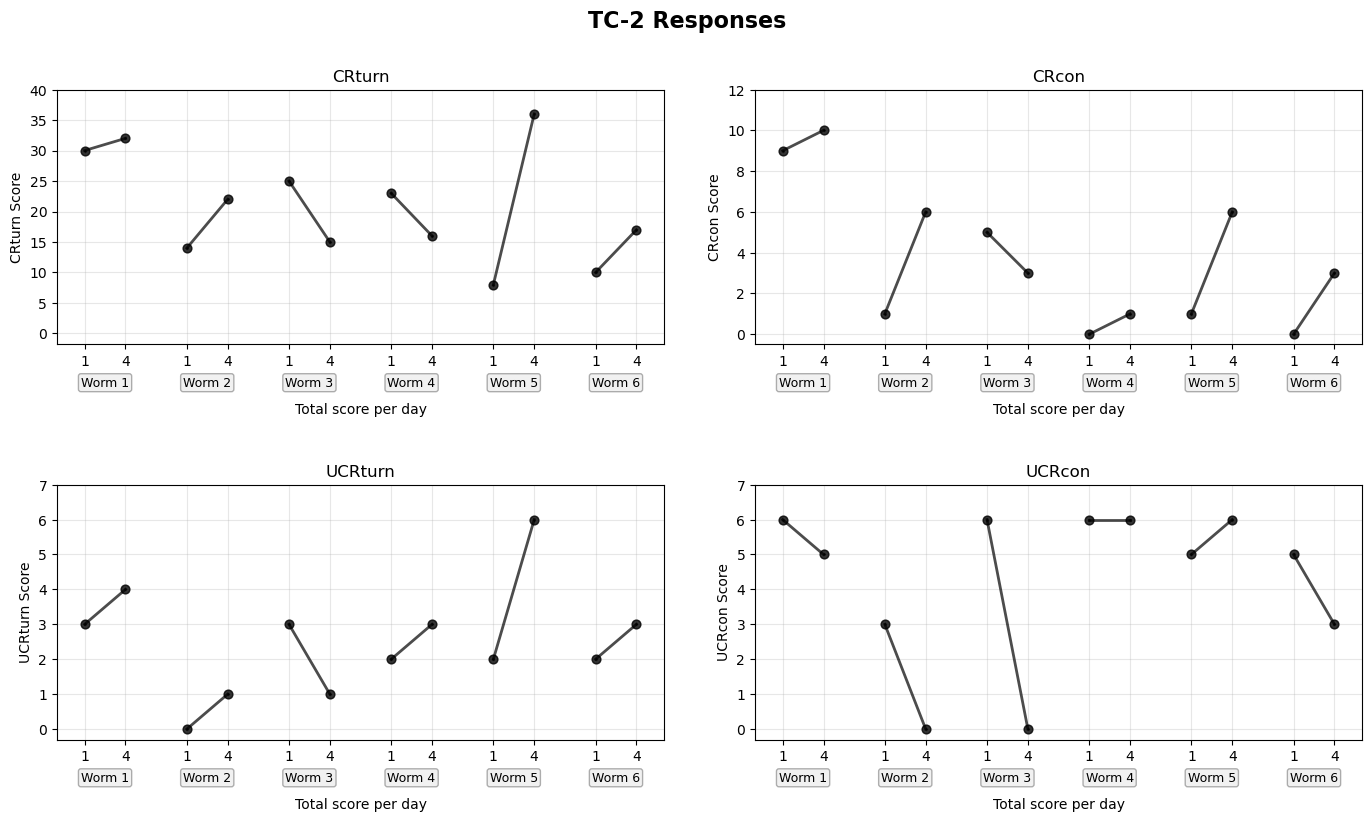

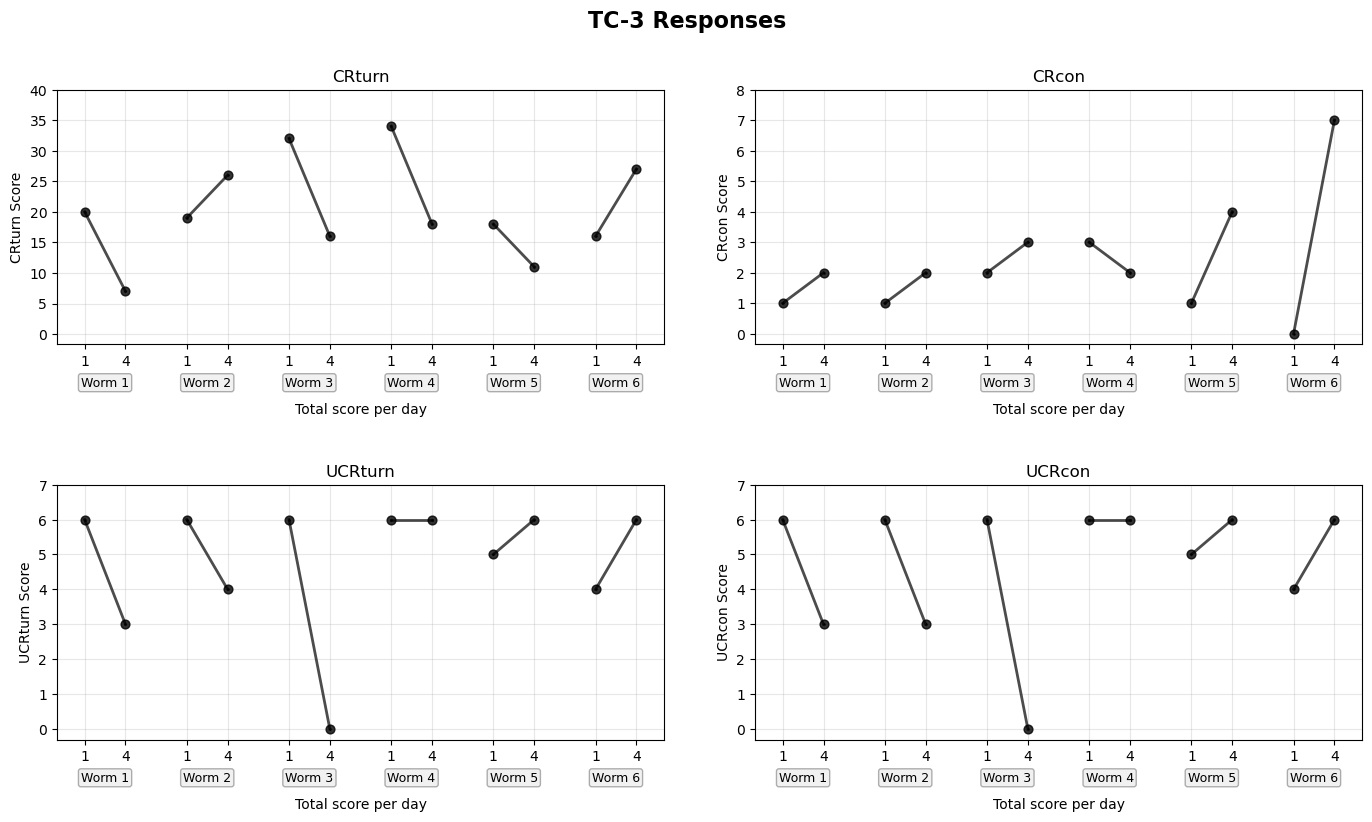

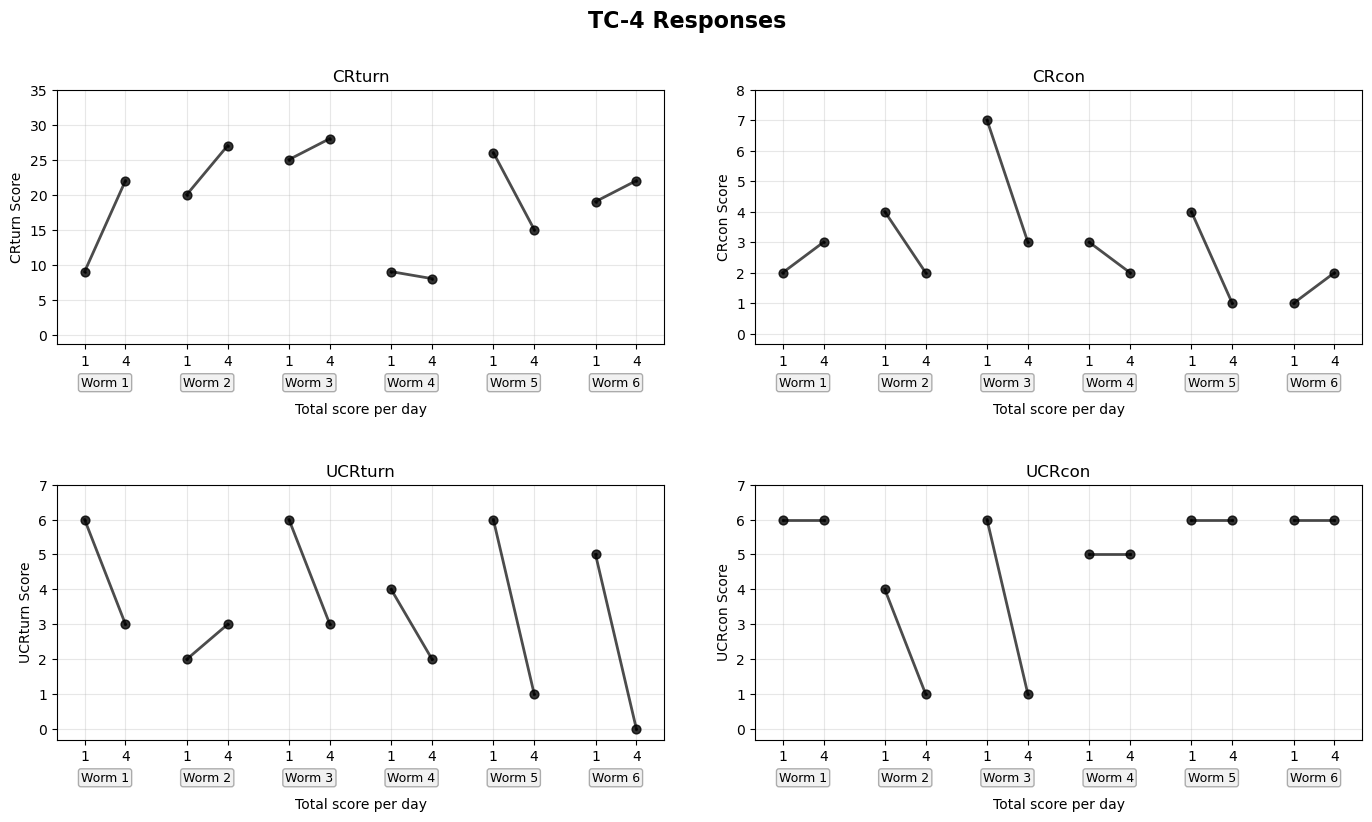

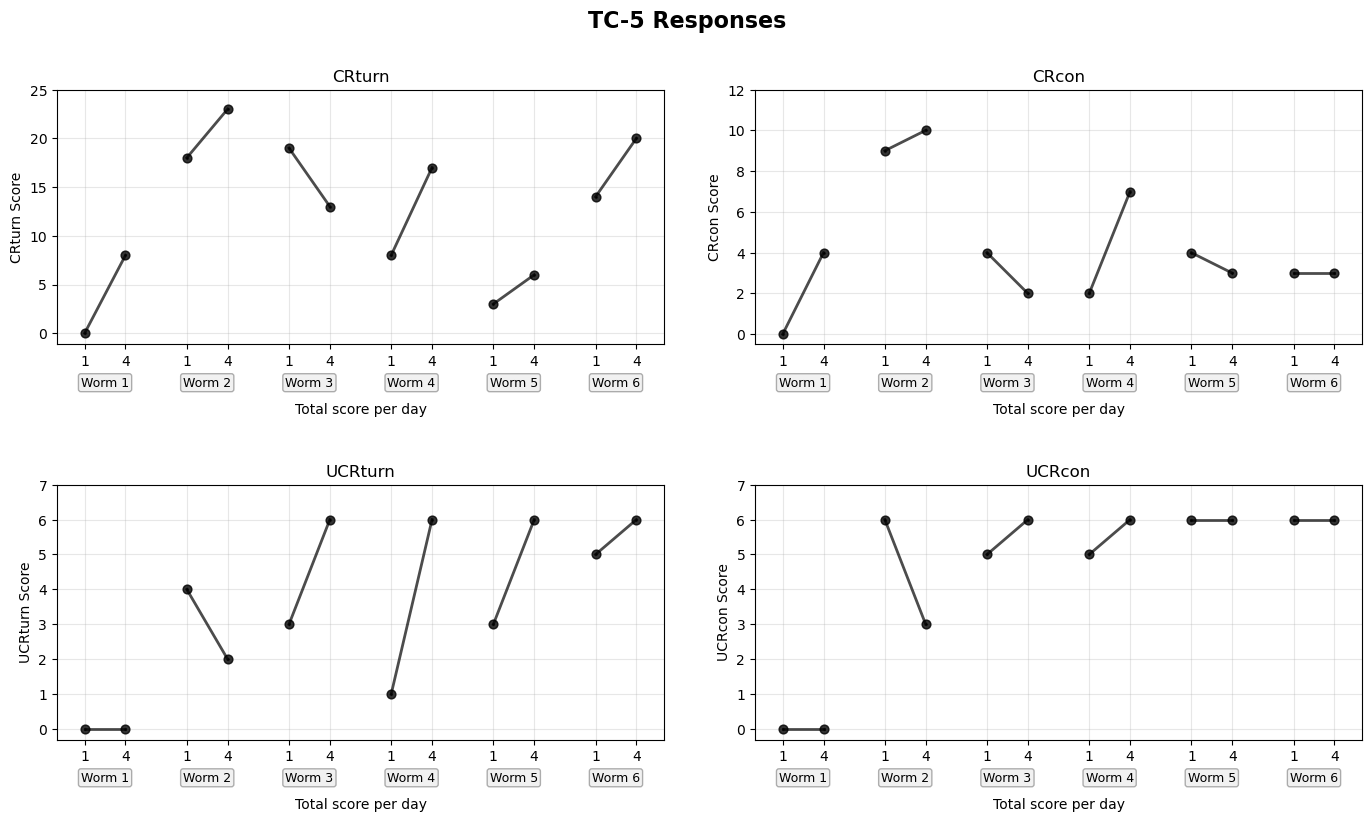

In [7]:
"""
There are two graphing functions.
1. create_behavior_graphs() - Shows all worms' data regardless of quality of UCRcon responses.
2. create_behavior_graphs_filtered() - Shows only  worms with UCRcon >= 4 on any given day; any failure disqualifies from display.

Arguments for both functions, in order:
- troupes: List like ['TC-1', 'TC-2'] or None for all troupes
- days: List like [1, 4] or None for all days  
- figsize: Tuple like (15, 10) for figure size in inches
- SAVE: True for save the images, False for don't.
"""

# All data:
# create_behavior_graphs()
# create_behavior_graphs_filtered()


# Specific analysis:
create_behavior_graphs(troupes=['TC-2', 'TC-3', 'TC-4', 'TC-5'], days=[1,4], SAVE=False)
# create_behavior_graphs_filtered(troupes=['TC-2', 'TC-3', 'TC-4', 'TC-5'], days=[1, 4], SAVE=True)


# Single troupe:
# create_behavior_graphs(troupes=['TC-1'])


# Custom size:
# create_behavior_graphs(figsize=(20, 15))


In [8]:
# Get per-worm CRcon sums for days 1–4 across all troupes
summary = analyze_raw_counts(troupes=None, days=[1, 4], verbose=False)

# Average CRcon across all worms and troupes for each day
# Average CRcon and standard error across all worms and troupes for each day
crcon_day_df = (
    summary  # from analyze_raw_counts(troupes=None, days=[1,2,3,4], verbose=False)
    .groupby('Day')['CRcon']
    .agg(['mean', 'std', 'count'])
    .reset_index()
    .rename(columns={'mean': 'CRcon_mean', 'std': 'CRcon_std', 'count': 'N'})
)

crcon_day_df['CRcon_sem'] = crcon_day_df['CRcon_std'] / np.sqrt(crcon_day_df['N'])


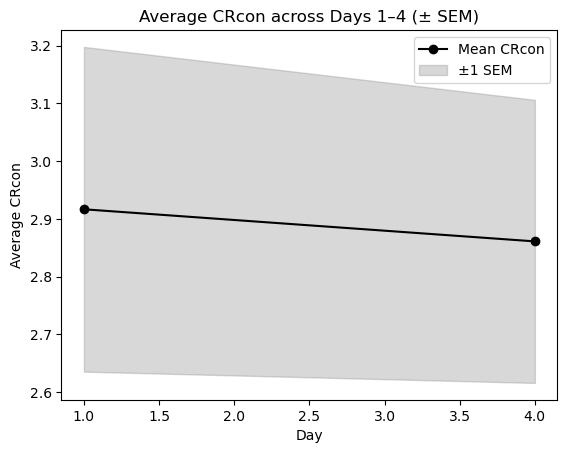

In [19]:
x = np.array(crcon_day_df['Day'])
y = np.array(crcon_day_df['CRcon_mean'])
sem = np.array(crcon_day_df['CRcon_sem'])

plt.figure()
plt.plot(x, y, marker='o', color='black', label='Mean CRcon')
plt.fill_between(x, y - sem, y + sem, color='gray', alpha=0.3, label='±1 SEM')
plt.xlabel('Day')
plt.ylabel('Average CRcon')
plt.title('Average CRcon across Days 1–4 (± SEM)')
plt.legend()
plt.show()

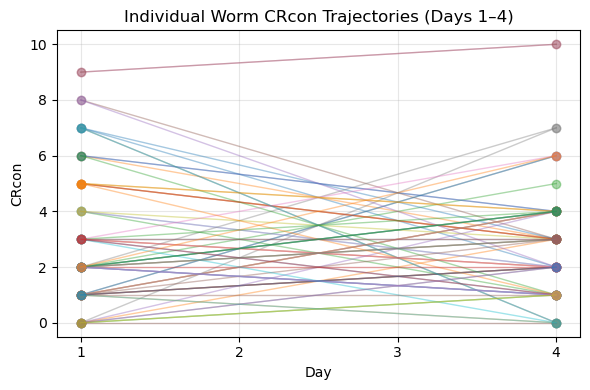

In [9]:
# Per-worm/day CRcon data, days 1–4
summary = analyze_raw_counts(troupes=None, days=[1, 4], verbose=False)

plt.figure(figsize=(6, 4))

for (troupe, worm), grp in summary.groupby(['Troupe', 'Worm']):
    grp_sorted = grp.sort_values('Day')
    plt.plot(
        np.array(grp_sorted['Day']),
        np.array(grp_sorted['CRcon']),
        marker='o',
        alpha=0.4,
        linewidth=1,
        label=f'{troupe} {worm}'  # comment this out if legend is too big
    )

plt.xlabel('Day')
plt.ylabel('CRcon')
plt.title('Individual Worm CRcon Trajectories (Days 1–4)')
# If too many lines, skip legend or limit it:
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)
plt.xticks([1, 2, 3, 4])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()